# PID Control of a Second Order System

## Preparations

Here we import all necessary libraries.

In [93]:
    from IPython.core.display import HTML
    import numpy as np
    
    import matplotlib.pyplot as plt
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "Helvetica",
        "font.size": 10,
    })
    
    from sympy import *
    from sympy.plotting import plot
    
    from mathprint import *

These are some variables that we are going to use: 

$t, s, \tau, \omega, \omega_n, \zeta$

In [94]:
from sympy.physics.control.lti import TransferFunction
Kp, Ki, Kd = symbols('K_p K_i K_d', positive=True)

t       = symbols('t', positive=True)
s       = symbols('s', complex=True)
tau     = symbols('tau', positive=True)

omega   = symbols("omega", positive=True)
omega_n = symbols('omega_n', positive=True)
zeta    = symbols('zeta', positive=True)

Let us define some helper functions.

In [95]:
def laplace(f):
    F = laplace_transform(f, t, s, noconds=True)
    return F

def ilaplace(F):
    f = inverse_laplace_transform(F, s, t)
    return f

def frac_to_tf(frac):
    return TransferFunction(fraction(frac)[0], fraction(frac)[1], s)

## System and the control equations

![](./images/p21.png)

The diagram above corresponds to a unity-feedback loop with

$$
G(s)=K_p+\frac{K_i}{s}+K_d
$$

and plant

$$
H(s)=\frac{1}{s^2 + 2 \zeta \omega_n s +\omega_n^2}.
$$

Thus, the closed-loop transfer function is

$$
\boxed{\frac{C(s)}{R(s)}
=
\frac{K_d s^2+K_p s+K_i}{s^2+\left(K_d+2 \omega_n\right) s^2+\left(K_p+\omega_n^2\right) s+K_i}}
$$

After this, we will compute $c(t)$, $c'(t)$, $c(0)$, $c'(0)$, and $c(\infty)$ where $c(t)$ is the inverse Laplace of $C(s)$. 

__From $c(\infty)$, we can get the steady state output of the controlled system while $c'(0)$ tells us the occurance of derivative kick in the controlled system (non-zero initial velocity).__



In [96]:
H = 1 / (s**2+2*zeta*omega_n*s+omega_n**2)
G = Kp + Ki/s + Kd*s        # PID TF
Q = factor(G*H / (1 + G*H)) # CL TF
Q = collect(Q, [s**3, s**2, s])

print("First-order system:")
mprint("H(s)=", latex(H))

print("PID-control:")
mprint("G(s)= ", latex(G))

print("The resulting closed-loop system:")
mprint("Q(s)=", latex(Q))

First-order system:


<IPython.core.display.Math object>

PID-control:


<IPython.core.display.Math object>

The resulting closed-loop system:


<IPython.core.display.Math object>

At this point, we can tell that the equations are already complicated, thus, finding some equations for further analysis might not be feasible. What we are going to do next is steady state analysis for several combinations of controller terms.

## Second-order system with P-control 

In [97]:
Qp = simplify(Q.subs(([Kd, 0],
                      [Ki, 0])))

mprint("Q_P=", latex(Qp))

<IPython.core.display.Math object>

For step response, we apply $1/s$ as its input, perform an inverse Laplace operation to $C(s)$ and obtain $c(t)$ as the result. Finally, we compute the steady state-value for the output: $c_{ss} = \lim_{t \to \infty} c(t)$.

In [98]:
cp = logcombine(ilaplace(Qp * 1/s))
cssp = simplify(limit(cp, t, 'oo'))
c0p  = limit(cp, t, 0)
cp_d  = simplify(diff(cp, t))
c0p_d  = limit(cp_d, t, 0)

mprint("c(t) = ", latex(cp))
mprint("c'(t) = ", latex(cp_d))
mprintb("c_{ss} = ", latex(cssp))
mprintb("c(0) = ", latex(c0p))
mprintb("c'(0) = ", latex(c0p_d))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Our conclusions: 
- no derivative kick
- smooth start
- zero initial velocity

Next, we can write the steady state error as: $e_{ss} = 1 - c_{ss}$

In [99]:
mprintb("e_{ss}=", latex(simplify(1-cssp)))

<IPython.core.display.Math object>

Next, let us try with some numerical valuses.

In [100]:
omega_n_ = 1
zeta_ = 1;
Kp_  = [1, 2, 4, 8, 20]

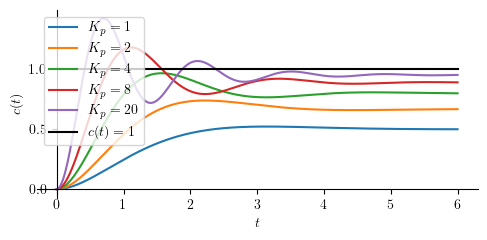

In [101]:
p = [plot(cp.subs(([zeta, zeta_], [omega_n, omega_n_], [Kp, Kp_[j]])), 
          (t, 0, 6), size=(5, 2.5), ylabel='$c(t)$', show=False, legend=True) 
     for j in range(len(Kp_))]

p1 = plot(1, (t, 0, 6), line_color='k', line_style=':', show=False) # unit-step
p1[0].label = "$c(t)=1$"
for j in range(len(p)):
    p[j][0].label = "$K_p=" + str(Kp_[j]) + "$"
    if j > 0:
        p[0].append(p[j][0])

p[0].append(p1[0])
p[0].show()

As evidenced by the gap between the response and the black target line, P-control results in a permanent steady-state offset. __The P-control cannot drive the error to zero__.

## Second-order system with PD-control 

Closed-loop transfer function:

In [102]:
Qpd = simplify(Q.subs(Ki, 0))
mprint("Q_{PD}=", latex(Qpd))


<IPython.core.display.Math object>

Next, we perform an inverse Laplace operation to $C(s)$ and obtain $c(t)$ as the result. Additionally, we will also compute the steady state-value for the output ($c_{ss}$).

A phenomenon that can be observed in a derivative control is the "kick" that happens when a step input is applied to the controlled system. Because of the kick, system output does not start from zero. 

In [103]:
cpd    = logcombine(ilaplace(Qpd * 1/s))
cpd_d  = powsimp(factor((diff(cpd, t))))

csspd = limit(cpd, t, 'oo')
c0pd  = limit(cpd, t, 0)
c0pd_d  = limit(cpd_d, t, 0)

mprint("\\small c(t) = ", latex(cpd))
mprint("\\small c'(t) = ", latex(cpd_d))
mprintb("c_{ss} = ", latex(csspd))
mprintb("c(0) = ", latex(c0pd))
mprintb("c'(0) = ", latex(c0pd_d))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Our conclusions: 
- derivative kick
- non-smooth start
- non-zero initial velocity

Next, we can write the steady state error as: $e_{ss} = 1 - c_{ss}$

In [104]:
mprintb("e_{ss}=", latex(simplify(1-csspd)))

<IPython.core.display.Math object>

In [105]:
omega_n_ = 1
zeta_ = 1;
Kp_  = 20
Kd_  = [1, 2, 5]

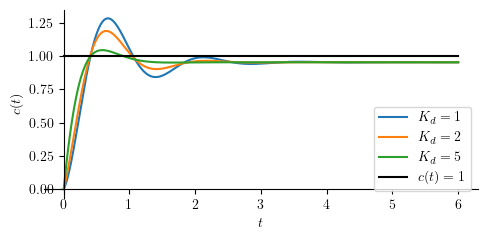

In [106]:
p = [plot(cpd.subs(([zeta, zeta_], [omega_n, omega_n_], [Kp, Kp_], [Kd, Kd_[j]])), 
          (t, 0, 6), size=(5, 2.5), ylabel='$c(t)$', show=False, legend=True, axis_center=[0,0]) 
     for j in range(len(Kd_))]
p1 = plot(1, (t, 0, 6), line_color='k', line_style=':', show=False) # unit-step
p1[0].label = "$c(t)=1$"
for j in range(len(p)):
    p[j][0].label = "$K_d=" + str(Kd_[j]) + "$"
    if j > 0:
        p[0].append(p[j][0])

p[0].append(p1[0])
p[0].show()


## Second-order system with PI-control 

Let us write down the closed-loop transfer function of a PI-controlled second-order system:

In [107]:
Qpi = simplify(Q.subs(Kd, 0))
mprintb("Q_{PI} =", latex(Qpi))

<IPython.core.display.Math object>

At this point we can no longer afford performing Inverse Laplace operation with SymPy since it is now involving finding root of a third orde polynomials. In order to find the steady state ouput, we will use __final value theorem__.

In [108]:
Cpi = Qpi*1/s
csspi = limit(s * Cpi, s, 0) 
mprint("C(s) =", latex(Cpi))
mprintb("c_{ss} = c(\\infty) =", latex(csspi))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

__At steady state, the output is 1 which means PI controlled system does not have steady state error.__

Next, we wll introduce $-a_1$, $-a_2$, and $-a_3$ as the roots of: $\left(K_i+2 \omega_n s^2 \zeta+s^3+s\left(K_p+\omega_n^2\right)\right)$

$$C(s)=\frac{K_i+K_p s}{s\left(K_i+2 \omega_n s^2 \zeta+s^3+s\left(K_p+\omega_n^2\right)\right)} = \frac{K_i+K_p s}{s(s+a_1)(s+a_3)(s+a_2)} $$

In [109]:
a1, a2, a3 = symbols('a1 a2 a3', complex=True)
Cpi_fac = (Kp*s + Ki) / (s*(s + a1)*(s + a2)*(s + a3))

mprint("C(s) = ", latex(Cpi_fac))

Cpi_pf = apart(Cpi_fac, s)

print("\nPartial fraction form")
mprint("C(s) = ", latex(Cpi_pf))

cpi = logcombine(inverse_laplace_transform(Cpi_pf, s, t))

print("\nInverse Laplace")
mprintb("c(t) = ", latex(cpi))

<IPython.core.display.Math object>


Partial fraction form


<IPython.core.display.Math object>


Inverse Laplace


<IPython.core.display.Math object>

We can now compute the intial output $c(0)$.

In [110]:
c0pi = simplify(cpi.subs(t, 0))
cpi_d = simplify(diff(cpi, t))
c0pi_d = limit(cpi_d, t, 0)

mprintb("c(0) = ", latex(c0pi))
mprint("c'(t) = ", latex(cpi_d))
mprintb("c'(0) = ", latex(c0pi_d))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Our conclusions: 
- no derivative kick
- smooth start
- zero initial velocity

Next, we can write the steady state error as: $e_{ss} = 1 - c_{ss}$

In this case, we will need to first find $a_1$, $a_2$, and $a_3$ (perhaps numerically). Then, we plug them into the later equation to find $c(t)$. Let us take some arbitrary numerical values so we can plot the controlled system's reponses.

In [111]:
tau_ = 1
Kp_ = 5
Ki_ = [0.5, 1, 2]
Kd_ = 0
omega_n_ = 1
zeta_ = 1

We must first calculate the denominator roots or $-a_1$, $-a_2$, and $-a_3$ by finding 3rd-order polynomial roots for each $K_i$.

In [112]:
ROOTS = []
for j in range(len(Ki_)):
    eq = Qpi.subs(([zeta, zeta_], [omega_n, omega_n_], [tau, tau_], [Kp, Kp_],[Ki, Ki_[j]]))
    root = solve(denom(eq),s)
    ROOTS.append([-root[k].evalf() for k in range(len(root))])
    mprint("K_i=", latex(Ki_[j]), "\\rightarrow", latex(ROOTS[j]))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

With $a_1$, $a_2$, and $a_3$ found, we now have the complete $c(t)$ responses for all $K_i$. This, we can plot the responses.

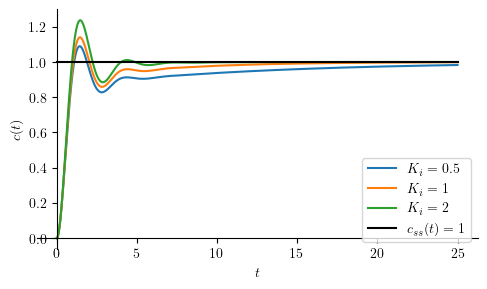

In [113]:
p = [plot(cpi.subs(([zeta, zeta_], [omega_n, omega_n_], [tau, tau_], [Kp, Kp_], [Ki, Ki_[j]],
                    [a1, ROOTS[j][0]], [a2, ROOTS[j][1]], [a3, ROOTS[j][2]])), (t, 0, 25), size=(5, 3), ylabel='$c(t)$', show=False, legend=True) for j in range(len(Ki_))]

for j in range(len(p)):
    p[j][0].label = "$K_i=" + str(Ki_[j]) + "$"
    if j > 0:
        p[0].append(p[j][0])

q = plot(csspi.subs(Kp, Kp_), (t, 0, 25), line_color='k', show=False)
q[0].label = "$ c_{ss} (t) = " + latex(csspi.subs(Kp, Kp_)) + " $"
p[0].append(q[0])
p[0].show()


## Second-order system with PID-control

This PID-control section is very similar to PI-control.

In [114]:
Qpid = Q
Cpid = Qpid * 1/s
mprint("Q_{PID}=", latex(Qpid))

csspid = limit(s * Cpid, s, 0) 
mprint("C(s) =", latex(Cpid))
mprintb("c_{ss} = c(\\infty) =", latex(csspid))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [115]:
a1, a2, a3 = symbols('a1 a2 a3', complex=True)
Cpid_fac = (Kd*s**2 + Kp*s + Ki) / (s*(s + a1)*(s + a2)*(s + a3))

mprint("C(s) = ", latex(Cpid_fac))

Cpid_pf = apart(Cpid_fac, s)

print("\nPartial fraction form")
mprint("C(s) = ", latex(Cpid_pf))

cpid = logcombine(inverse_laplace_transform(Cpid_pf, s, t))

print("\nInverse Laplace")
mprintb("c(t) = ", latex(cpid))

<IPython.core.display.Math object>


Partial fraction form


<IPython.core.display.Math object>


Inverse Laplace


<IPython.core.display.Math object>

In [116]:
c0pid = simplify(cpid.subs(t, 0))
cpid_d = simplify(diff(cpid, t))
c0pid_d = simplify(limit(cpid_d, t, 0))

mprintb("c(0) = ", latex(c0pid))
mprint("c'(t) = ", latex(cpid_d))
mprintb("c'(0) = ", latex(c0pid_d))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Our conclusions: 
- derivative kick
- non-smooth start
- non-zero initial velocity

Next, we can write the steady state error as: $e_{ss} = 1 - c_{ss}$

In [117]:
mprintb("e_{ss}=", latex(simplify(1-csspid)))

<IPython.core.display.Math object>

## Summary

### Initial and steady-state output for unit-step input

In [118]:
from pandas import DataFrame, set_option
from IPython.display import Markdown, display

def makelatex(args):
    return ["${}$".format(latex(a)) for a in args]

descs = ["P", 
         "PD",
         "PI",
         "PID"]

css_label = [cssp, csspd, csspi, csspid]
c_label   = [cp, cpd, cpi, cpid]
init      = [c0p, c0pd, c0pid, c0pid]
initd     = [c0p_d, c0pd_d, c0pi_d, c0pid_d]

dic = {''         : makelatex(descs), 
       '$c_{ss}$' : makelatex(css_label),
       '$c(0)$'   : makelatex(init),
       "$c'(0)$"  : makelatex(initd)}


df = DataFrame(dic)


In [119]:
Markdown(df1.to_markdown(index=False))

|                       | $c_{ss}$                               | $c(0)$   | $c'(0)$   |
|:----------------------|:---------------------------------------|:---------|:----------|
| $\mathtt{\text{P}}$   | $\frac{K_{p}}{K_{p} + \omega_{n}^{2}}$ | $0$      | $0$       |
| $\mathtt{\text{PD}}$  | $\frac{K_{p}}{K_{p} + \omega_{n}^{2}}$ | $0$      | $K_{d}$   |
| $\mathtt{\text{PI}}$  | $1$                                    | $0$      | $0$       |
| $\mathtt{\text{PID}}$ | $1$                                    | $0$      | $K_{d}$   |